In [1]:
import numpy as np
import torch
from sympy.abc import alpha

from pid.models import CartesianProductFlow, BroadcastChannelFlow
from pid.optimizers import exact_gauss_tilde_pid, exact_gauss_thin_pid, flow_pid

from pid.utils import generate_randomBC
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
dm = 2  # Number of dimensions of M
dx = 512
dy = 512

# set manual seed
torch.manual_seed(0)
np.random.seed(0)

hx, hy = generate_randomBC(dm, dx, dy)

sigm = np.eye(dm)
sigx_m = np.eye(dx)
sigy_m = np.eye(dy)
sigw = np.zeros((dx, dy))

# Covariance matrix construction for both unique or redundant
cov = np.block([[sigm, sigm @ hx.T, sigm @ hy.T],
                [hx @ sigm, hx @ sigm @ hx.T + sigx_m, hx @ sigm @ hy.T + sigw],
                [hy @ sigm, hy @ sigm @ hx.T + sigw.T, hy @ sigm @ hy.T + sigy_m]])

print(cov.shape)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"GPID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(6, 6)
GPID: R: 0.7940917538598677, U1: 1.465651967941114, U2: 0.5871380333059419, S: 0.18473288934145016


In [3]:
n = 10000

# set manual seed
torch.manual_seed(10)
np.random.seed(10)

mean = np.zeros(dm+dx+dy)
mxy = np.random.multivariate_normal(mean, cov, size=n)
cov = np.corrcoef(mxy.T)

mean = np.zeros(dm+dx+dy)
mxy = np.random.multivariate_normal(mean, cov, size=n)
m_data, x_data, y_data = np.hsplit(mxy, [dm, dm+dx])  # split m, x, y
print(m_data.shape, x_data.shape, y_data.shape)

x_data = x_data**3
y_data = np.cbrt(y_data)
m_data = np.cbrt(m_data)

(10000, 2) (10000, 2) (10000, 2)


In [4]:
new_mxy = np.hstack((m_data, x_data, y_data))
new_cov = np.corrcoef(new_mxy.T)
print(new_cov.shape)

ret = exact_gauss_tilde_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Tilde-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(6, 6)
Tilde-PID: R: 0.18319132216766865, U1: 0.2979793849463722, U2: 0.7614866071778145, S: 0.02217616930031263
Thin-PID: R: 0.18319129510366738, U1: 0.2979794120103735, U2: 0.7614866342418157, S: 0.02217614223631137


In [5]:
def standardize_data(data):
    data = np.nan_to_num((data - data.mean(axis=0)) / data.std(axis=0))
    data = np.clip(data, a_min=-10, a_max=10)
    return data

m_data_standardized = standardize_data(m_data)
x_data_standardized = standardize_data(x_data)
y_data_standardized = standardize_data(y_data)

standard_mxy = np.hstack((m_data_standardized, x_data_standardized, y_data_standardized))
standard_cov = np.corrcoef(standard_mxy.T)
print(new_cov.shape)

(6, 6)


In [6]:
dataset = TensorDataset(
    torch.from_numpy(x_data_standardized).float(),
    torch.from_numpy(y_data_standardized).float(),
    torch.from_numpy(m_data_standardized).float(),
)
train_loader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)
train_iter = iter(train_loader)

In [7]:
import pid.models.lmi as lmi

###### flow pid ######
enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

latent_dim = 16

model = CartesianProductFlow(
    dm=dm,
    dx=dx,
    dy=dy,
    n_flows=6,
).to(device)

Using device: cuda


In [8]:
# Train model
max_iter = 5000

loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iter, eta_min=1e-4)

for i in tqdm(range(max_iter)):
    try:
        x, y, m = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, y, m = next(train_iter)
    optimizer.zero_grad()
    loss = model.learning_loss(m.to(device), x.to(device), y.to(device))

    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
        scheduler.step()

    loss_hist = np.append(loss_hist, loss.detach().to('cpu').numpy())

print(f"Final loss: {loss_hist[-1]}")

100%|██████████| 5000/5000 [02:30<00:00, 33.21it/s]

Final loss: -3.2995290756225586


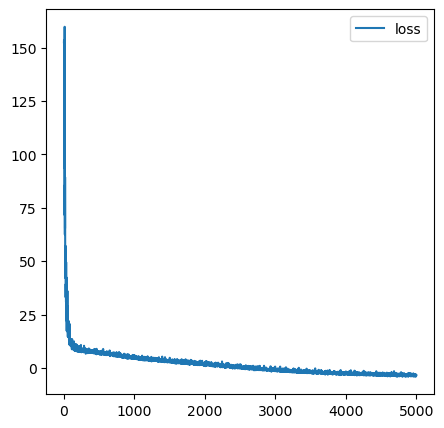

In [9]:
plt.figure(figsize=(5, 5))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

In [10]:
ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"GPID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_tilde_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Tilde-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

# pid_flow = flow_pid.fit_flows(model, dataloader, n_epochs=50, lr=2e-4, device=device, verbose=True)
ret = flow_pid.fit_pid(model, train_loader, device=device, verbose=True)
norm = ret[7] + ret[5] + ret[6] + ret[8]
print(f"Flow PID, R: {ret[7]}, U1: {ret[5]}, U2: {ret[6]}, S: {ret[8]}")

GPID: R: 0.8161953126633037, U1: 1.45295566091436, U2: 0.580504474763408, S: 0.19035103413618737
Tilde-PID: R: 0.18319132216766865, U1: 0.2979793849463722, U2: 0.7614866071778145, S: 0.02217616930031263
Thin-PID: R: 0.18319129510366738, U1: 0.2979794120103735, U2: 0.7614866342418157, S: 0.02217614223631137
Flow PID, R: 0.4706981443436711, U1: 0.9801375745515039, U2: 0.47009697573514386, S: 0.11548576358105511
